# <u>Submission instructions</u>
### Submission in pairs unless otherwise authorized
<ul style="font-size: 17px">
<li> This notebook contains all the questions. You should follow the instructions below.</li>
<li> Solutions for both theoretical and practical parts should be provided in this notebook</li>
</ul>

<h3> Moodle submission</h3>


<p style="font-size: 17px">
You should submit three files:
</p>
<ul style="font-size: 17px">
<li>IPYNB notebook:
  <ul>
  <li>All the wet and dry parts, including code, graphs, discussion, etc.</li>
  </ul>
</li>
<li>PDF file:
  <ul>
  <li>Export the notebook to PDF. Make sure that all the cells are visible.</li>
  </ul>
</li>
<li>Pickle files:
  <ul>
    <li>As requested in Q3.2.a and Q4.a</li>
  </ul>
</li>
</ul>
<p style="font-size: 17px">
All files should be in the following format: "HW1_ID1_ID2.file"
<br>
Good Luck!
</p>

# Question 1 (15pt)

We mentioned in the lecture and tutorial that neural networks, thanks to their non-linear activation functions, can express a much wider range of functions than just linear ones.

In each of the following exercises, you are given the weight matrices, biases and activations of a small neural network. Express the network's output as a simplified, well-known mathematical function and provide a short explanation. There is no need to prove correctness, an intuitive explanation is enough.

The activation function (non-linearity) is denoted as $g$. The output is given by:

$$s = W_2 g(W_1 x + b_1) + b_2.$$

In network 4, we also apply the activation to the final output, meaning the network's output is $g(s)$. When not stated otherwise, the bias vector is 0.

#**Network 1**

$$x \in \mathbb{R}. \quad W_1=\begin{pmatrix} 1 \\ -1\end{pmatrix}, W_2 = \begin{pmatrix} 1 & 1\end{pmatrix}. \quad g=\text{ReLU}.$$

### **Step 1: First layer output**

$$
h = g(W_1 x)
= g\!\left( \begin{pmatrix} 1 \\ -1 \end{pmatrix} x \right)
= g\!\left( \begin{pmatrix} x \\ -x \end{pmatrix} \right)
= \begin{pmatrix} \max(0,x) \\ \max(0,-x) \end{pmatrix}.
$$

### **Step 2: Final output**

$$
s = W_2 h
= (1 \;\; 1)
\begin{pmatrix}  \max(0,x) \\ \max(0,-x) \end{pmatrix}
= \max(0,x) + \max(0,-x).
$$



### **Step 3: Case analysis**

- If $x \ge 0$: $\max(0,x)=x$ and $\max(0,-x)=0$, so $s = x$.

- If $x \lt 0$: $\max(0,x)=0$ and $\max(0,-x)=-x$, so $s = -x$.

### **Final result**

$$
s(x) = |x|
$$

The network computes the **absolute value function**.


#**Network 2**
$$x \in \mathbb{R}^2. \quad W_1 = \begin{pmatrix}-1 & 1 \\ 1 & 0 \\ -1 & 0\end{pmatrix}, W_2 = \begin{pmatrix}1 & 1 & -1\end{pmatrix}. \quad g=\text{ReLU}.$$

Let $x = (x_1, x_2)^T$.

### **Step 1: First layer output**

Compute $W_1 x$:

$$
W_1 x
=
\begin{pmatrix}
-1 & 1 \\
1 & 0 \\
-1 & 0
\end{pmatrix}
\begin{pmatrix} x_1 \\ x_2 \end{pmatrix}
=
\begin{pmatrix}
-x_1 + x_2 \\
x_1 \\
-x_1
\end{pmatrix}
$$

Apply ReLU elementwise:

$$
h = g(W_1 x)
= \begin{pmatrix}
\max(0, -x_1 + x_2) \\
\max(0, x_1) \\
\max(0, -x_1)
\end{pmatrix}
$$

### **Step 2: Final output**

$$
s = W_2 h
= (1 \;\; 1 \;\; -1)
\begin{pmatrix}
\max(0, -x_1 + x_2) \\
\max(0, x_1) \\
\max(0, -x_1)
\end{pmatrix}
$$

Thus:

$$
s(x_1, x_2)
= \max(0, -x_1 + x_2)
+ \max(0, x_1)
- \max(0, -x_1)
$$

### **Step 3: Simplification**

Note:

- $\max(0, x_1) - \max(0, -x_1) = x_1$  
  (this is a known identity: ReLU$(x) -$ ReLU$(-x) = x$)

So the output simplifies to:

$$
s(x_1, x_2)
= x_1 + \max(0,\, x_2 - x_1)
$$

### **Final Result**

$$
s(x_1, x_2) =
\begin{cases}
x_1, & x_1 \ge x_2, \\\\
x_2, & x_2 \ge x_1.
\end{cases}
$$

Equivalently:

$$
s(x_1, x_2) = \max(x_1, x_2).
$$

The network computes the **maximum** of the two input coordinates.

#**Network 3**
$$x=\begin{pmatrix}x_1 \\ x_2 \\ y_1 \\ y_2\end{pmatrix} \in \mathbb{R}^4. \quad W_1 = \begin{pmatrix} 1 & 0 & -1 & 0 \\ -1 & 0 & 1 & 0 \\ 0 & 1 & 0 & -1 \\ 0 & -1 & 0 & 1\end{pmatrix}, W_2 = \begin{pmatrix} 1 & 1 & 1 & 1 \end{pmatrix}. \quad g = \text{ReLU}.$$

We have  
$x = (x_1, x_2, x_3, x_4)^T \in \mathbb{R}^4$,  

$$
W_1 =
\begin{pmatrix}
1 & 0 & -1 & 0 \\
-1 & 0 &  1 & 0 \\
0 & 1 &  0 & -1 \\
0 & -1 & 0 &  1
\end{pmatrix},
\qquad
W_2 = (1 \;\; 1 \;\; 1 \;\; 1),
\qquad
g = \text{ReLU}.
$$

### **First layer**

$$
W_1 x =
\begin{pmatrix}
x_1 - x_3 \\
- x_1 + x_3 \\
x_2 - x_4 \\
- x_2 + x_4
\end{pmatrix}
$$

Apply ReLU elementwise:

$$
h = g(W_1 x) =
\begin{pmatrix}
\max(0, x_1 - x_3) \\
\max(0, -x_1 + x_3) \\
\max(0, x_2 - x_4) \\
\max(0, -x_2 + x_4)
\end{pmatrix}.
$$

### **Second layer**

$$
s = W_2 h
= \max(0, x_1 - x_3) + \max(0, x_3 - x_1)
+ \max(0, x_2 - x_4) + \max(0, x_4 - x_2)
$$

### **Final Result**

Use the identity $\max(0,a) + \max(0,-a) = |a|$:

$$
s(x_1,x_2,x_3,x_4)
= |x_1 - x_3| + |x_2 - x_4|
$$


So Network 3 computes the **$L^1$ distance (Manhattan distance)** between the points $(x_1,x_2)$ and $(x_3,x_4)$


#**Network 4**
Here, the non-linearity is applied also to the output of the second layer. For simplicity, assume $ \forall x \ge 10, \text{sigmoid}(x) = 1, \text{sigmoid}(-x) = 0$.

$$x \in \{0, 1\}^2 \quad \text{(binary vector)}.$$

$$W_1 = \begin{pmatrix} 20 & 20 \\ -20 & -20 \end{pmatrix}, b_1 = \begin{pmatrix} -10 \\ 30 \end{pmatrix}, W_2 = \begin{pmatrix} 20 & 20 \end{pmatrix}, b_2 = -30. \quad g=\text{sigmoid}.$$

Let $x = (x_1, x_2)^T$, with $x_1, x_2 \in \{0,1\}$.

## **Step 1 — First layer**

Compute:

$$
z = W_1 x + b_1
=
\begin{pmatrix}
20(x_1 + x_2) - 10 \\
-20(x_1 + x_2) + 30
\end{pmatrix}.
$$

Then:

$$
h = g(z) =
\begin{pmatrix}
\sigma(20(x_1 + x_2) - 10) \\
\sigma(-20(x_1 + x_2) + 30)
\end{pmatrix}
$$


## **Step 2 — Evaluate all 4 binary inputs**

We evaluate $\sigma$ using the given approximation:
- $\sigma(z) = 0$ when $z \le -10$
- $\sigma(z) = 1$ when $z \ge 10$

### $\cdot$ Case 1: $(x_1, x_2) = (0,0)$

$x_1 + x_2 = 0:$

$$
z = \begin{pmatrix} -10 \\ 30 \end{pmatrix}
\;\Rightarrow\;
h = (\sigma(-10), \sigma(30)) = (0,1)
$$

Second layer:
$$
u = W_2 h + b_2 = 20(0 + 1) - 30 = -10
$$

Final output:
$$
s = \sigma(-10) = 0
$$


### $\cdot$ Case 2: $(x_1, x_2) = (0,1)$

$x_1 + x_2 = 1:$

$$
z = \begin{pmatrix} 10 \\ 10 \end{pmatrix}
\;\Rightarrow\;
h = (\sigma(10), \sigma(10)) = (1,1)
$$

Second layer:
$$
u = 20(1+1) - 30 = 10
$$

Final output:
$$
s = \sigma(10) = 1
$$


### $\cdot$ Case 3: $(x_1, x_2) = (1,0)$

Same as case 2:

$$
h = (1,1), \qquad u = 10, \qquad s = 1
$$


### $\cdot$ Case 4: $(x_1, x_2) = (1,1)$

$x_1 + x_2 = 2$

$$
z = \begin{pmatrix} 30 \\ -10 \end{pmatrix}
\;\Rightarrow\;
h = (\sigma(30), \sigma(-10)) = (1,0)
$$

Second layer:
$$
u = 20(1 + 0) - 30 = -10
$$

Final output:
$$
s = \sigma(-10) = 0
$$



# **Step 3 — Final truth table**

| $(x_1,x_2)$ | output $s$ |
|-------------|------------|
| (0,0) | 0 |
| (0,1) | 1 |
| (1,0) | 1 |
| (1,1) | 0 |


## **Final Result**

$$
s(x_1,x_2) =
\begin{cases}
1, & x_1 \ne x_2, \\
0, & x_1 = x_2.
\end{cases}
$$

Therefore:

The network computes **XOR**:
$$
s(x_1,x_2) = x_1 \oplus x_2.
$$


# Question 2

We recommend checking the hidden slides in tutorial 1 before approaching these exercises.

## I. Softmax Derivative (5pt)

Derive the gradients of the softmax function and demonstrate how the expression can be reformulated solely by using the softmax function, i.e., in some expression where only $\text{softmax}(x)$, but not $x$, is present. Recall that the softmax function is defined as follows:

$$\text{softmax}(x)_i = \frac{e^{x_i}}{\sum_{j=1}^{N} e^{x_j}}$$

### I. Softmax Derivative - Answer:
$$\frac{\partial softmax(x)_i}{\partial x_k} = \text{...}$$

First, let's consider the case where $i \ne k$:

$$
\frac{\partial \text{softmax}(x)_i}{\partial x_k} = \frac{-e^{x_i}e^{x_k}}{(\sum_{j=1}^{N} e^{x_j})^2}
$$

Otherwise,  $i = k:$
$$
\frac{\partial \text{softmax}(x)_i}{\partial x_k} = \frac{e^{x_i}}{\sum_{j=1}^{N} e^{x_j}} \cdot \left( 1 - \frac{e^{x_k}}{\sum_{j=1}^{N} e^{x_j}} \right)
$$

Let the Kronecker delta defined as:

$$
\delta_{ik} =
\begin{cases}
1, & i = k, \\
0, & i \ne k.
\end{cases}
$$

Now:
$$
\frac{\partial \text{softmax}(x)_i}{\partial x_k} = \frac{e^{x_i}}{\sum_{j=1}^{N} e^{x_j}} \cdot \left( \delta_{ik} - \frac{e^{x_k}}{\sum_{j=1}^{N} e^{x_j}} \right)
$$

**Final Answer:**

$$
\frac{\partial \text{softmax}(x)_i}{\partial x_k} =
\begin{cases}
  \text{softmax}(x)_i (1 - \text{softmax}(x)_i) & \text{if } i = k \\
  -\text{softmax}(x)_i \cdot \text{softmax}(x)_k & \text{if } i \neq k
\end{cases}
$$


## II. Cross-Entropy Gradient (5pt)

Derive the gradient of cross-entropy loss with regard to the inputs of a softmax function. i.e., find the gradients with respect to the softmax input vector $\theta$, when the prediction is denoted by $\hat{y} = \text{softmax}(\theta)$. Remember the cross entropy function is:
$$CE(y, \hat{y}) = -\sum_i y_i log(\hat{y_i})$$


where $y$ is the one-hot label vector, and $\hat{y}$ is the predicted probability vector for all classes.

### II. Cross-Entropy Gradient - Answer

We are given:
- Prediction: $\hat{\mathbf{y}} = \mathrm{softmax}(\boldsymbol{\theta})$
- Cross-entropy loss:
  $$
  CE(\mathbf{y}, \hat{\mathbf{y}}) = -\sum_i y_i \log(\hat{y}_i),
  $$
  where $\mathbf{y}$ is a one-hot label vector.

## **Step 1**
We want the gradient by $\theta_k$:

According to chain rule:
$$
\frac{\partial CE}{\partial \theta_k}
= -\sum_i y_i \frac{1}{\hat{y}_i} \frac{\partial \hat{y}_i}{\partial \theta_k}.
$$


## **Step 2**

Recall the softmax:
$$
\hat{y}_i = \mathrm{softmax}({\theta})_i = \frac{e^{\theta_i}}{\sum_j e^{\theta_j}}.
$$

According to part I:
$$
\frac{\partial \hat{y}_i}{\partial \theta_k}
= \hat{y}_i \left( \delta_{ik} - \hat{y}_k \right),
$$
   where the Kronecker delta is
$$
\delta_{ik} =
\begin{cases}
1, & i = k, \\
0, & i \ne k.
\end{cases}
$$


## **Step 3**
Substitute this into the chain rule:

$$
\frac{\partial CE}{\partial \theta_k}
= -\sum_i y_i \frac{1}{\hat{y}_i}
\left[ \hat{y}_i (\delta_{ik} - \hat{y}_k) \right]
= -\sum_i y_i (\delta_{ik} - \hat{y}_k) = -\sum_i y_i \delta_{ik} + \sum_i y_i \hat{y}_k
$$


Since $y$ is one-hot:
- $\displaystyle \sum_i y_i \delta_{ik} = y_k$  
- $\displaystyle \sum_i y_i = 1 \Rightarrow \sum_i y_i \hat{y}_k = \hat{y}_k$

So:
$$
\frac{\partial CE}{\partial \theta_k}
= -y_k + \hat{y}_k.
$$


## **Final Answer**

$$
\frac{\partial CE(\mathbf{y}, \hat{\mathbf{y}})}{\partial \theta}
= \hat{y} - y
$$

Infect:

$$
\boxed{
\frac{\partial CE(\mathbf{y}, \hat{\mathbf{y}})}{\partial \theta}
= \mathrm{softmax} - y
}
$$


# Question 3

## I. Derivative Of Activation Functions (5pt)

The following cell contains an implementation of some activation functions. Implement the corresponding derivatives.

In [ ]:
import torch

def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def tanh(x):
    return torch.div(torch.exp(x) - torch.exp(-x), torch.exp(x) + torch.exp(-x))


def softmax(x):
    exp_x = torch.exp(x.T - torch.max(x, dim=-1).values).T  # Subtracting max(x) for numerical stability
    return exp_x / exp_x.sum(dim=-1, keepdim=True)

In [ ]:
def d_sigmoid(x):
    sigmoid_x = sigmoid(x)
    return sigmoid_x * (1 - sigmoid_x)


def d_tanh(x):
    tanh_x = tanh(x)
    return 1 - tanh_x**2


def d_softmax(x):
  softmax = softmax(x)
  softmax = softmax.squeeze()
  softmax_jacobian = torch.diag(s) - torch.outer(s, s)
  return softmax_jacobian



## II. Train a Fully Connected network on MNIST (30pt)

In the following exercise, you will create a classifier for the MNIST dataset.
You should write your own training and evaluation code and meet the following
constraints:
<ul>
<li> You are only allowed to use torch tensor manipulations.</li>
<li> You are NOT allowed to use:
  <ul>
  <li> Auto-differentiation - backward()</li>
  <li> Built-in loss functions</li>
  <li> Built-in activations</li>
  <li> Built-in optimization</li>
  <li> Built-in layers (torch.nn)</li>
  </ul>
  </li>
</ul>
</h4>

a. The required classifier class is defined.

You should implement the forward and backward passes of the model.
Train the model and plot the model's accuracy and loss (both on train and test sets) as a function of the epochs.
You should save the model's weights and biases. Change the student_ids to yours.

In this section, you <b>must</b> use the "set_seed" function with the given seed and <b>sigmoid</b> as an activation function.

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader

import os
import matplotlib.pyplot as plt

# Constants
SEED = 42
EPOCHS = 16
BATCH_SIZE = 32
NUM_OF_CLASSES = 10

# Setting seed
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


# Transformation for the data
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torch.flatten])


# Cross-Entropy loss implementation
def one_hot(y, num_of_classes=10):
    hot = torch.zeros((y.size()[0], num_of_classes))
    hot[torch.arange(y.size()[0]), y] = 1
    return hot

def cross_entropy(y, y_hat):
    return -torch.sum(one_hot(y) * torch.log(y_hat)) / y.size()[0]

In [ ]:
# Create dataloaders
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                            download=True, transform=transform)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE)


test_dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                           download=True, transform=transform)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE,)

100%|██████████| 9.91M/9.91M [00:00<00:00, 48.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.64MB/s]


In [ ]:
class FullyConnectedNetwork:
    def __init__(self, input_size, output_size, hidden_size1, activiation_func, lr=0.01):
        # parameters
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size1 = hidden_size1

        # activation function
        self.activation_func = activiation_func

        # weights
        self.W1 = torch.randn(self.input_size, self.hidden_size1)
        self.b1 = torch.zeros(self.hidden_size1)

        self.W2 = torch.randn(self.hidden_size1, self.output_size)
        self.b2 = torch.zeros(self.output_size)

        self.lr = lr

    def forward(self, x):
        z1 = torch.matmul(x, self.W1) + self.b1
        h1 = self.activation_func(z1)
        z2 = torch.matmul(h1, self.W2) + self.b2
        y_hat = softmax(z2)
        return y_hat

    def backward(self, x, y, y_hat):
        z1 = torch.matmul(x, self.W1) + self.b1
        dz2 = y_hat - one_hot(y)
        self.W2.grad = torch.matmul(self.activation_func(torch.matmul(x, self.W1) + self.b1).T, dz2)
        self.b2.grad = dz2.sum(dim=0)
        dz1 = torch.matmul(dz2, self.W2.T) * self.activation_func(z1) * (1 - self.activation_func(z1))
        self.W1.grad = torch.matmul(x.T, dz1)
        self.b1.grad = dz1.sum(dim=0)

    def step(self):
        # Gradient descent step
        self.W1.data -= self.lr * self.W1.grad
        self.b1.data -= self.lr * self.b1.grad
        self.W2.data -= self.lr * self.W2.grad
        self.b2.data -= self.lr * self.b2.grad

        # Zero out gradients for the next iteration
        self.W1.grad.zero_()
        self.b1.grad.zero_()
        self.W2.grad.zero_()
        self.b2.grad.zero_()

In [ ]:
set_seed(SEED)
model = FullyConnectedNetwork(784, 10, 128, sigmoid, lr=0.01)

In [ ]:
def train_model_and_plot(model,EPOCHS):
  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []

  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []

  for epoch in range(EPOCHS):
      total_loss = 0
      correct_train = 0

      for images, labels in train_dataloader:
          images = images.view(images.shape[0], -1)

          # Forward pass
          y_hat = model.forward(images)
          loss = cross_entropy(labels, y_hat)

          # Backward pass
          model.backward(images, labels, y_hat)

          # Gradient descent step
          model.step()

          total_loss += loss.item()
          predicted_labels = torch.argmax(y_hat, dim=1)
          correct_train += (predicted_labels == labels).sum().item()

      average_loss = total_loss / len(train_dataloader)
      accuracy_train = correct_train / len(train_dataset)
      train_losses.append(average_loss)
      train_accuracies.append(accuracy_train)

      # Evaluate on the test set
      model.W1.requires_grad_(False)
      model.b1.requires_grad_(False)
      model.W2.requires_grad_(False)
      model.b2.requires_grad_(False)

      total_loss = 0
      correct_test = 0

      for images, labels in test_dataloader:
          images = images.view(images.shape[0], -1)
          y_hat = model.forward(images)
          loss = cross_entropy(labels, y_hat)
          total_loss += loss.item()
          predicted_labels = torch.argmax(y_hat, dim=1)
          correct_test += (predicted_labels == labels).sum().item()

      model.W1.requires_grad_(True)
      model.b1.requires_grad_(True)
      model.W2.requires_grad_(True)
      model.b2.requires_grad_(True)

      average_loss = total_loss / len(test_dataloader)
      accuracy_test = correct_test / len(test_dataset)
      test_losses.append(average_loss)
      test_accuracies.append(accuracy_test)
      print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {average_loss:.4f}, Train Accuracy: {accuracy_train:.4f}, Test Accuracy: {accuracy_test:.4f}")

  plt.figure(figsize=(18, 4))  # Adjust the figsize as needed

  # Subplot 1
  plt.subplot(1, 3, 1)
  plt.plot(train_losses, label='Train Loss')
  plt.plot(test_losses, label='Test Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  # Subplot 2
  plt.subplot(1, 3, 2)
  plt.plot(train_accuracies, label='Train Accuracy')
  plt.plot(test_accuracies, label='Test Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()


  plt.show()



In [ ]:
students_ids = "207413360_322836180"
torch.save({"W1": model.W1, "W2": model.W2, "b1": model.b1, "b2": model.b2}, f"HW1_{207413360_322836180}.pkl")

b. Train the model with various learning rates (at least 3).

Plot the model's accuracy and loss (both on train and test sets) as a function of the epochs.
Discuss the differences in training with different learning rates. Support your answer with plots.

Epoch 1/16, Loss: 0.2327, Train Accuracy: 0.8910, Test Accuracy: 0.9328
Epoch 2/16, Loss: 0.1777, Train Accuracy: 0.9470, Test Accuracy: 0.9493
Epoch 3/16, Loss: 0.1663, Train Accuracy: 0.9604, Test Accuracy: 0.9510
Epoch 4/16, Loss: 0.1579, Train Accuracy: 0.9692, Test Accuracy: 0.9557
Epoch 5/16, Loss: 0.1584, Train Accuracy: 0.9746, Test Accuracy: 0.9571
Epoch 6/16, Loss: 0.1494, Train Accuracy: 0.9783, Test Accuracy: 0.9569
Epoch 7/16, Loss: 0.1500, Train Accuracy: 0.9824, Test Accuracy: 0.9597
Epoch 8/16, Loss: 0.1583, Train Accuracy: 0.9846, Test Accuracy: 0.9594
Epoch 9/16, Loss: 0.1528, Train Accuracy: 0.9866, Test Accuracy: 0.9601
Epoch 10/16, Loss: 0.1654, Train Accuracy: 0.9892, Test Accuracy: 0.9575
Epoch 11/16, Loss: 0.1627, Train Accuracy: 0.9890, Test Accuracy: 0.9616
Epoch 12/16, Loss: 0.1600, Train Accuracy: 0.9909, Test Accuracy: 0.9604
Epoch 13/16, Loss: 0.1574, Train Accuracy: 0.9932, Test Accuracy: 0.9633
Epoch 14/16, Loss: 0.1616, Train Accuracy: 0.9946, Test Accu

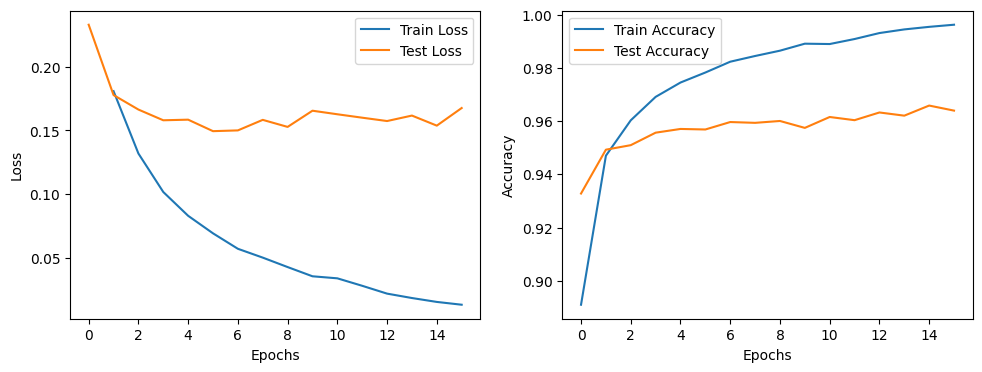

Epoch 1/16, Loss: 0.3671, Train Accuracy: 0.8272, Test Accuracy: 0.8919
Epoch 2/16, Loss: 0.2958, Train Accuracy: 0.9097, Test Accuracy: 0.9108
Epoch 3/16, Loss: 0.2624, Train Accuracy: 0.9278, Test Accuracy: 0.9217
Epoch 4/16, Loss: 0.2429, Train Accuracy: 0.9374, Test Accuracy: 0.9274
Epoch 5/16, Loss: 0.2287, Train Accuracy: 0.9446, Test Accuracy: 0.9308
Epoch 6/16, Loss: 0.2178, Train Accuracy: 0.9501, Test Accuracy: 0.9341
Epoch 7/16, Loss: 0.2096, Train Accuracy: 0.9550, Test Accuracy: 0.9365
Epoch 8/16, Loss: 0.2032, Train Accuracy: 0.9591, Test Accuracy: 0.9387
Epoch 9/16, Loss: 0.1978, Train Accuracy: 0.9621, Test Accuracy: 0.9408
Epoch 10/16, Loss: 0.1933, Train Accuracy: 0.9649, Test Accuracy: 0.9430
Epoch 11/16, Loss: 0.1894, Train Accuracy: 0.9671, Test Accuracy: 0.9450
Epoch 12/16, Loss: 0.1862, Train Accuracy: 0.9693, Test Accuracy: 0.9461
Epoch 13/16, Loss: 0.1834, Train Accuracy: 0.9713, Test Accuracy: 0.9466
Epoch 14/16, Loss: 0.1811, Train Accuracy: 0.9733, Test Accu

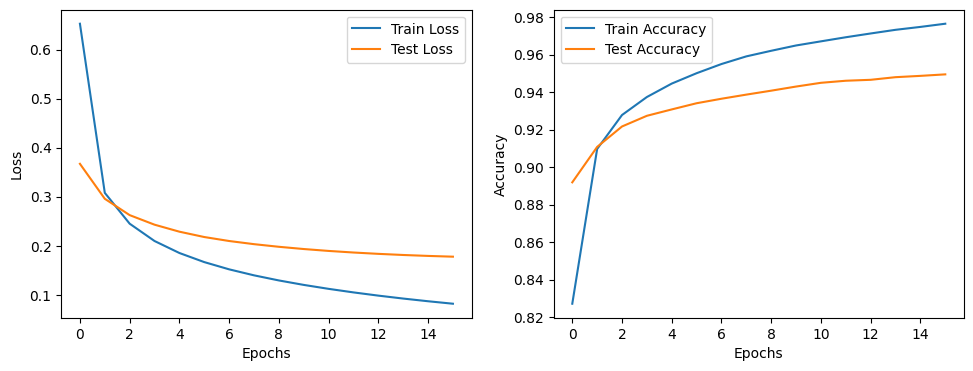

Epoch 1/16, Loss: 0.9602, Train Accuracy: 0.5787, Test Accuracy: 0.7478
Epoch 2/16, Loss: 0.7014, Train Accuracy: 0.7809, Test Accuracy: 0.8110
Epoch 3/16, Loss: 0.5901, Train Accuracy: 0.8247, Test Accuracy: 0.8376
Epoch 4/16, Loss: 0.5237, Train Accuracy: 0.8480, Test Accuracy: 0.8545
Epoch 5/16, Loss: 0.4781, Train Accuracy: 0.8630, Test Accuracy: 0.8654
Epoch 6/16, Loss: 0.4443, Train Accuracy: 0.8736, Test Accuracy: 0.8748
Epoch 7/16, Loss: 0.4180, Train Accuracy: 0.8821, Test Accuracy: 0.8803
Epoch 8/16, Loss: 0.3967, Train Accuracy: 0.8890, Test Accuracy: 0.8851
Epoch 9/16, Loss: 0.3791, Train Accuracy: 0.8949, Test Accuracy: 0.8894
Epoch 10/16, Loss: 0.3641, Train Accuracy: 0.8995, Test Accuracy: 0.8926
Epoch 11/16, Loss: 0.3513, Train Accuracy: 0.9040, Test Accuracy: 0.8963
Epoch 12/16, Loss: 0.3402, Train Accuracy: 0.9076, Test Accuracy: 0.8993
Epoch 13/16, Loss: 0.3304, Train Accuracy: 0.9110, Test Accuracy: 0.9017
Epoch 14/16, Loss: 0.3218, Train Accuracy: 0.9138, Test Accu

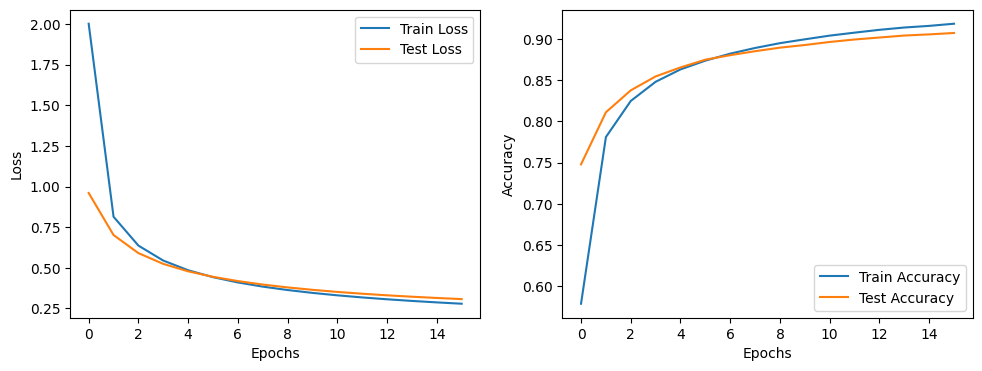

In [ ]:
model_1 = FullyConnectedNetwork(784, 10, 128, sigmoid, lr=0.1)
train_model_and_plot(model_1,EPOCHS)
model_2 = FullyConnectedNetwork(784, 10, 128, sigmoid, lr=0.01)
train_model_and_plot(model_2,EPOCHS)
model_3 = FullyConnectedNetwork(784, 10, 128, sigmoid, lr=0.001)
train_model_and_plot(model_3,EPOCHS)

In [ ]:
torch.save({"W1": model.W1, "W2": model.W2, "b1": model.b1, "b2": model.b2}, f"HW1_{207413360_322836180}.pkl")

# Question 4

We recommend using GPUs to solve this section. You can use free GPUs provided by Google Colab or by Kaggle (instructions on how to connect are in Moodle). Also, we recommend going over all tutorial notebooks and using dropout, normalization and Adam for better learning. Solving this on your personal computer will be significantly slower than using cloud computation.

## I. Implement and Train a CNN (30pt)

Whenever Ben sees a cat, his first instinct is to run up and pet them. However, after a recent incident he realized not all types of cats are very fond of that type of attention. Train a classifier to tell the difference between different types of big cats, and help Ben from putting himself in too much danger.

Your code should meet the following constraints:

1. Your classifier must be CNN based.
2. You are not allowed to use any pre-trained model.

#### Stages
1. Perform a short EDA (Exploratory Data Analysis).
2. Train the model and plot its accuracy and loss (for both the training and validation sets) as a function of the epochs. Display the overall number of parameters in the model. To see the number of parameters in your model, run `sum(p.numel() for p in model.parameters())`.
3. Report the test set accuracy.

 Your data is in `hw1_data/big_cats`.

You can use the provided code for preprocessing the data. You can also define a custom dataset (as in tutorial 3) or use `torchvision.datasets.ImageFolder` if you prefer. **Your training function must call the `set_seed` command for reproducibility**.

 #### Submission
In addition to the code in the notebook, you should submit:

1. a `.py` file containing your model class.
2. a `.pkl` file containing the weight of your model.

#### Grading
- 5 points for EDA.
- 15 points based on reaching minimum test accuracy (77% accuracy required to get all 15 points, 70% accuracy to get 10 points).
- 10 points competitive: try to balance the tradeoff between number of parameters in your model and model's test accuracy. The lower the # of parameters and the higher the test accuracy, the higher the final score.

In [ ]:
!unzip "/content/hw1_data.zip" -d /content/

Archive:  /content/hw1_data.zip
   creating: /content/big_cats/
   creating: /content/big_cats/valid/
   creating: /content/big_cats/valid/SNOW LEOPARD/
  inflating: /content/big_cats/valid/SNOW LEOPARD/4.jpg  
  inflating: /content/big_cats/valid/SNOW LEOPARD/5.jpg  
  inflating: /content/big_cats/valid/SNOW LEOPARD/2.jpg  
  inflating: /content/big_cats/valid/SNOW LEOPARD/3.jpg  
  inflating: /content/big_cats/valid/SNOW LEOPARD/1.jpg  
   creating: /content/big_cats/valid/OCELOT/
  inflating: /content/big_cats/valid/OCELOT/4.jpg  
  inflating: /content/big_cats/valid/OCELOT/5.jpg  
  inflating: /content/big_cats/valid/OCELOT/2.jpg  
  inflating: /content/big_cats/valid/OCELOT/3.jpg  
  inflating: /content/big_cats/valid/OCELOT/1.jpg  
   creating: /content/big_cats/valid/PUMA/
  inflating: /content/big_cats/valid/PUMA/4.jpg  
  inflating: /content/big_cats/valid/PUMA/5.jpg  
  inflating: /content/big_cats/valid/PUMA/2.jpg  
  inflating: /content/big_cats/valid/PUMA/3.jpg  
  inflati

In [ ]:
# =====================
# 1. IMPORTS & SETUP
# =====================
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

def set_seed(seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# =====================
# 2. DATASET DEFINITON
# =====================
class BigCatDataset(Dataset):
    def __init__(self, root_dir, train=True):
        self.root_dir = root_dir

        if train:
            # Augmentation + normalize (TRAIN ONLY)
            self.transform = transforms.Compose([
                transforms.Resize((128, 128)),
                transforms.RandomHorizontalFlip(0.5),
                transforms.RandomRotation(10),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                )
            ])
        else:
            # Only resize + normalize (VAL/TEST)
            self.transform = transforms.Compose([
                transforms.Resize((128, 128)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                )
            ])

        classes = [
            os.path.join(root_dir, c)
            for c in os.listdir(root_dir)
            if not c.startswith('.')
        ]

        self.data = [os.path.join(c, d) for c in classes for d in os.listdir(c)]
        self.classes = sorted([c.split('/')[-1] for c in classes])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        cls_name = img_path.split('/')[-2]
        cls_id = self.classes.index(cls_name)

        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, cls_id

In [ ]:
# =====================
# 3. LOAD DATASETS
# =====================
train = BigCatDataset('/content/big_cats/train', train=True)
val   = BigCatDataset('/content/big_cats/valid', train=False)
test  = BigCatDataset('/content/big_cats/test',  train=False)

train_loader = DataLoader(train, batch_size=32, shuffle=True)
val_loader   = DataLoader(val, batch_size=32)
test_loader  = DataLoader(test, batch_size=32)

print("Classes:", train.classes)
print("Train size:", len(train))
print("Valid size:", len(val))
print("Test size:", len(test))


Classes: ['AFRICAN LEOPARD', 'CARACAL', 'CHEETAH', 'CLOUDED LEOPARD', 'JAGUAR', 'LIONS', 'OCELOT', 'PUMA', 'SNOW LEOPARD', 'TIGER']
Train size: 2339
Valid size: 50
Test size: 50


In [ ]:
# =====================
# 4. MODEL DEFINITION
# =====================
class BigCatCNN(nn.Module):
    def __init__(self, num_classes):
        super(BigCatCNN, self).__init__()

        # Block 1: 3x128x128 -> 16x64x64
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)          # 128 -> 64
        )

        # Block 2: 16x64x64 -> 32x32x32
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)          # 64 -> 32
        )

        # Block 3: 32x32x32 -> 64x16x16
        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)          # 32 -> 16
        )

        # Block 4: 64x16x16 -> 96x8x8
        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)          # 16 -> 8
        )

        # Block 5: 96x8x8 -> 96x4x4
        self.layer5 = nn.Sequential(
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)          # 8 -> 4
        )

        self.dropout = nn.Dropout(p=0.5)

        # אחרי 5 בלוקים: 96x4x4 = 1536 פיצ'רים
        self.fc1 = nn.Linear(96 * 4 * 4, 96)
        self.fc2 = nn.Linear(96, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)      # flatten -> (batch, 1536)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# =====================
# 5. TRAINING LOOP
# =====================
def train_model(model, train_loader, val_loader, epochs=40, lr=5e-4):
    set_seed(0)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=15, gamma=0.5)
    loss_fn = nn.CrossEntropyLoss()

    train_acc_hist, val_acc_hist = [], []
    train_loss_hist, val_loss_hist = [], []

    for epoch in range(epochs):

        # TRAIN
        model.train()
        correct = total = 0
        total_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            opt.zero_grad()
            out = model(imgs)
            loss = loss_fn(out, labels)
            loss.backward()
            opt.step()

            total_loss += loss.item()
            _, pred = torch.max(out, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # VALID
        model.eval()
        correct = total = 0
        total_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                loss = loss_fn(out, labels)

                total_loss += loss.item()
                _, pred = torch.max(out, 1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)

        val_loss = total_loss / len(val_loader)
        val_acc = correct / total

        scheduler.step()

        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)

        print(f"Epoch {epoch+1}: Train acc={train_acc:.3f}, Val acc={val_acc:.3f}")

    return train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist

Total parameters: 311146
Epoch 1: Train acc=0.289, Val acc=0.520
Epoch 2: Train acc=0.449, Val acc=0.420
Epoch 3: Train acc=0.508, Val acc=0.520
Epoch 4: Train acc=0.563, Val acc=0.500
Epoch 5: Train acc=0.614, Val acc=0.400
Epoch 6: Train acc=0.623, Val acc=0.580
Epoch 7: Train acc=0.656, Val acc=0.620
Epoch 8: Train acc=0.672, Val acc=0.580
Epoch 9: Train acc=0.698, Val acc=0.480
Epoch 10: Train acc=0.696, Val acc=0.620
Epoch 11: Train acc=0.714, Val acc=0.640
Epoch 12: Train acc=0.751, Val acc=0.620
Epoch 13: Train acc=0.730, Val acc=0.680
Epoch 14: Train acc=0.752, Val acc=0.600
Epoch 15: Train acc=0.780, Val acc=0.740
Epoch 16: Train acc=0.814, Val acc=0.700
Epoch 17: Train acc=0.813, Val acc=0.740
Epoch 18: Train acc=0.820, Val acc=0.680
Epoch 19: Train acc=0.853, Val acc=0.780
Epoch 20: Train acc=0.821, Val acc=0.800
Epoch 21: Train acc=0.841, Val acc=0.820
Epoch 22: Train acc=0.855, Val acc=0.780
Epoch 23: Train acc=0.865, Val acc=0.740
Epoch 24: Train acc=0.862, Val acc=0.740


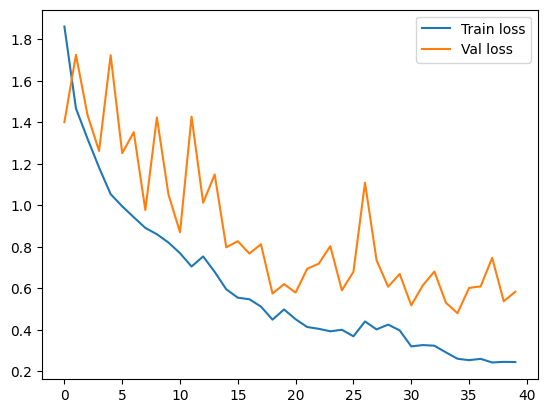

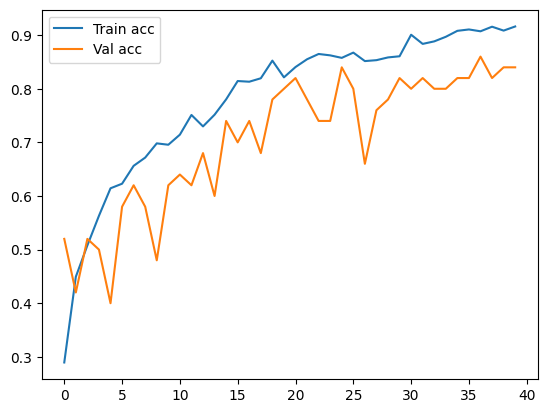

In [ ]:
# =====================
# 6. TRAIN MODEL
# =====================
model = BigCatCNN(num_classes=len(train.classes))
num_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", num_params)
train_loss, val_loss, train_acc, val_acc = train_model(model, train_loader, val_loader)

plt.plot(train_loss, label="Train loss")
plt.plot(val_loss, label="Val loss")
plt.legend()
plt.show()

plt.plot(train_acc, label="Train acc")
plt.plot(val_acc, label="Val acc")
plt.legend()
plt.show()

In [ ]:
# =====================
# 7. TEST EVALUATION
# =====================
def evaluate(model, loader):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            _, pred = torch.max(out, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

    return correct / total

test_acc = evaluate(model, test_loader)
print("Test accuracy:", test_acc)

Test accuracy: 0.92


In [ ]:
torch.save(model.state_dict(), "bigcat_model.pkl")
print("Saved model weights!")

Saved model weights!


## II. Analyzing a Pre-trained CNN (Filters) (10pt)

In this part, you are going to analyze a (large) pre-trained model. Pre-trained models are quite popular these days, as big companies can train really large models on large datasets (something that personal users can't do as they lack the sufficient hardware). These pre-trained models can be used to fine-tune on other/small datasets or used as components in other tasks (like using a pre-trained classifier for object detection).

All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

You can use the following transform to normalize:

`normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`
<a href="https://pytorch.org/vision/stable/models.html">Read more here</a>


1. Load a pre-trained VGG16 with PyTorch using `torchvision.models.vgg16(pretrained=True, progress=True, **kwargs)` (<a href="https://pytorch.org/vision/stable/models.html#classification">read more here</a>). Don't forget to use the model in evaluation mode (`model.eval()`).

2. Load the images in the `hw1_data/birds` folder and display them.

3. Pre-process the images to fit VGG16's architecture. What steps did you take?

4. Feed the images (forward pass) to the model. What are the outputs?

5. Choose an image of a dog in the `hw1_data/dogs` folder, display it and feed it to network. What are the outputs?

6. For the first 3 filters in the first layer of VGG16, plot their response (their output) for the image from section 5. Explain what do you see.

#### 1. Load the model:

In [ ]:
import torchvision
model = torchvision.models.vgg16(pretrained=True, progress=True)
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

2. Plot the bird images:

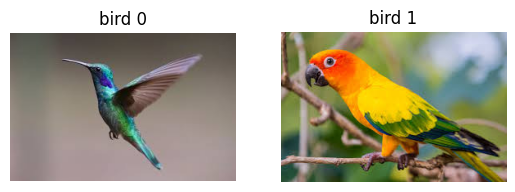

In [ ]:
plt.subplot(1, 2, 1)
im = Image.open(("./birds/bird_0.jpg"))
plt.imshow(im)
plt.axis('off')
plt.title("bird 0")
plt.subplot(1, 2, 2)
im = Image.open(("./birds/bird_1.jpg"))
plt.imshow(im)
plt.axis('off')
plt.title("bird 1")
plt.show()

3. Preprocess the images:

To do so, we resized the images to (3, 224, 224) so they can fit the model requirments, normalized the data with the given mean and std, transformed them to tensor and unsqueezed them to fit the reuired batch size of the model.

In [ ]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

bird_0 = Image.open("./birds/bird_0.jpg")
bird_0 = preprocess(bird_0)
bird_0 = bird_0.unsqueeze(0)

bird_1 = Image.open("./birds/bird_1.jpg")
bird_1 = preprocess(bird_1)
bird_1 = bird_1.unsqueeze(0)

4. Feed the images to the model:

In [ ]:
out = model(bird_0)
print("bird 0: ", torch.max(out ,1)[1])
out = model(bird_1)
print("bird 1: ", torch.max(out ,1)[1])

bird 0:  tensor([94])
bird 1:  tensor([90])


In [ ]:
import json
import urllib.request

# load imagenet class index
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
class_idx = urllib.request.urlopen(url).read().decode().splitlines()

print(class_idx[94])
print(class_idx[90])


hummingbird
lorikeet


As we can see, the outputs are 94 for the bird 0 and 90 for the bird 1, and as written in the imagenet_class_index json file that show what is the label of each index, the label of the bird 0 is hummingbird, and the bird 1 is lorikeet.


5. We choosed to diplay the picture dog_1:

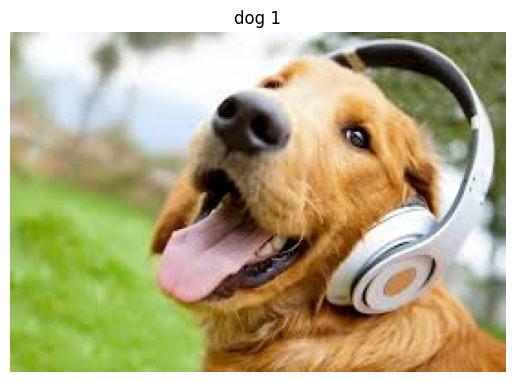

dog 1 index: 207
dog 1 class: golden retriever


In [ ]:
import urllib.request
im = Image.open(("./dogs/dog_1.jpg"))
plt.imshow(im)
plt.axis('off')
plt.title("dog 1")
plt.show()

# Load ImageNet class names (once)
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = urllib.request.urlopen(url).read().decode().splitlines()

# Dog 1 prediction
im = preprocess(Image.open("./dogs/dog_1.jpg"))
output = model(im.unsqueeze(0))

# get predicted index
idx = torch.max(output, 1)[1].item()

# get predicted class name
class_name = imagenet_classes[idx]

print("dog 1 index:", idx)
print("dog 1 class:", class_name)


As we can see, the output is 207, and as written in the imagenet_class_index json file that shows what is the label of each index, the label of this image is golden_retriever.



6. Display the first 3 filters of the model and display the output if these filters on our dog picture.

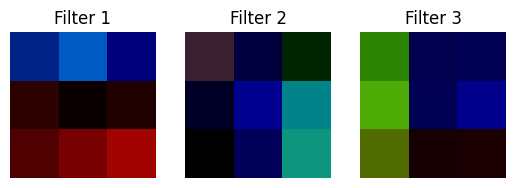

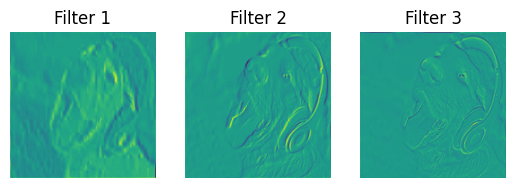

In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.models as models

for i in range(3):
    filter_i = model.features[0].weight.data[i].numpy()
    plt.subplot(1, 3, i+1)
    plt.imshow(filter_i)
    plt.axis('off')
    plt.title('Filter {}'.format(i+1))

plt.show()

dog_1 = Image.open("./dogs/dog_1.jpg")  # Replace "input_image.jpg" with the path to your image
dog_1 = preprocess(dog_1)
dog_1 = dog_1.unsqueeze(0)


for i in range(3):
    filter_i = model.features[0].weight.data[i]
    filtered_image = torch.nn.functional.conv2d(dog_1, filter_i.unsqueeze(0), padding=1)
    plt.subplot(1, 3, i+1)
    plt.imshow(filtered_image.squeeze(0).permute(1, 2, 0).detach().numpy())
    plt.axis('off')
    plt.title('Filter {}'.format(i+1))

plt.show()


We can see that the filters did succeed to locate the dog, and we can see that the third filter tries to focus on the details of the picture, but the first one do that less but give a clearer focus on the shape of the dog, and the second tries to balance between showing details and focusing on the dog shape.